# Fase 3 — Treinamento dos Modelos
---

## Fase 1 — Baseline

Antes de treinar qualquer modelo real, precisamos saber qual é o **piso mínimo de desempenho** — o resultado que obteríamos sem aprender absolutamente nada dos dados.

Para isso usamos o `DummyClassifier` com estratégia `stratified`: ele sorteia as predições respeitando a proporção das classes no treino (6.2% inadimplente, 93.8% adimplente), sem olhar para nenhuma feature.

**Por que isso importa?**  
Se um modelo que não aprende nada já atinge AUC de 0.52, um modelo real com AUC de 0.55 praticamente não está agregando valor. O baseline é a régua de comparação para tudo que vem depois.

> **Contexto do dataset**
> | | Treino | Teste |
> |---|---|---|
> | Total de amostras | 160 | 40 |
> | Inadimplentes (1) | 10 (6.2%) | 3 (7.5%) |
> | Adimplentes (0) | 150 (93.8%) | 37 (92.5%) |
> | Features | 64 | 64 |
> | Ratio desbalanceamento | **1:15** | 1:12.3 |

---

### Decisões de implementação

**`RepeatedStratifiedKFold(n_splits=5, n_repeats=10)` em vez de `StratifiedKFold(n_splits=5)`**

Com apenas 10 inadimplentes no treino, cada fold de validação contém em média **2 inadimplentes**. Com 2 amostras da classe minoritária, o AUC é extremamente sensível ao acaso da divisão — basta um fold "sortear melhor" para o desvio padrão explodir, como visto no baseline anterior onde um único fold atingiu 0.73 enquanto os outros ficaram em 0.47.

O `RepeatedStratifiedKFold` repete o CV 10 vezes com seeds diferentes, gerando **50 estimativas** em vez de 5. A média converge e o desvio padrão passa a refletir o modelo, não o acaso da divisão.

**PR-AUC (`average_precision`) como segunda métrica**

Em dados muito desbalanceados, o ROC-AUC pode ser otimista porque considera os verdadeiros negativos (adimplentes), que são maioria. A curva Precision-Recall foca apenas nas classes positivas, sendo mais sensível à qualidade da separação na classe minoritária. As duas métricas juntas dão uma visão mais completa.

## 0. Importações

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import os
import json

warnings.filterwarnings('ignore')

from sklearn.dummy import DummyClassifier
from sklearn.model_selection import RepeatedStratifiedKFold, cross_val_score
from sklearn.metrics import roc_auc_score, average_precision_score, roc_curve

RANDOM_STATE = 42
N_SPLITS     = 5
N_REPEATS    = 10   # 5 × 10 = 50 estimativas de AUC

sns.set_style('whitegrid')
print('Importações concluídas.')

Importações concluídas.


## 1. Carregando os Dados

In [2]:
treino = pd.read_csv('../dados/tratados/treino_preprocessado.csv')
teste  = pd.read_csv('../dados/tratados/teste_preprocessado.csv')

X_treino = treino.drop(columns=['inadimplente'])
y_treino = treino['inadimplente']

X_teste  = teste.drop(columns=['inadimplente'])
y_teste  = teste['inadimplente']

print(f'Treino : {X_treino.shape[0]} amostras | {X_treino.shape[1]} features')
print(f'Teste  : {X_teste.shape[0]} amostras  | {X_teste.shape[1]} features')
print()
print('Distribuição da classe alvo:')
print(f'  Treino → 0: {(y_treino==0).sum()}  1: {(y_treino==1).sum()}  ({y_treino.mean()*100:.1f}% inadimplente)')
print(f'  Teste  → 0: {(y_teste==0).sum()}   1: {(y_teste==1).sum()}   ({y_teste.mean()*100:.1f}% inadimplente)')

Treino : 160 amostras | 64 features
Teste  : 40 amostras  | 64 features

Distribuição da classe alvo:
  Treino → 0: 150  1: 10  (6.2% inadimplente)
  Teste  → 0: 37   1: 3   (7.5% inadimplente)


## 2. Definindo a Estratégia de Cross-Validation

O `RepeatedStratifiedKFold` será reutilizado em todas as fases seguintes. Definido aqui uma vez, aplicado em todo o restante do notebook.

In [3]:
rskf = RepeatedStratifiedKFold(
    n_splits  = N_SPLITS,
    n_repeats = N_REPEATS,
    random_state = RANDOM_STATE
)

print(f'Estratégia: RepeatedStratifiedKFold')
print(f'  n_splits  = {N_SPLITS}')
print(f'  n_repeats = {N_REPEATS}')
print(f'  Total de estimativas por modelo: {N_SPLITS * N_REPEATS}')
print()
print('Comparação com a estratégia anterior:')
print(f'  StratifiedKFold(5)          →  5 estimativas, std alto por acaso da divisão')
print(f'  RepeatedStratifiedKFold(5×10) → 50 estimativas, std estável e confiável')

Estratégia: RepeatedStratifiedKFold
  n_splits  = 5
  n_repeats = 10
  Total de estimativas por modelo: 50

Comparação com a estratégia anterior:
  StratifiedKFold(5)          →  5 estimativas, std alto por acaso da divisão
  RepeatedStratifiedKFold(5×10) → 50 estimativas, std estável e confiável


## 3. Treinamento do Baseline

O `DummyClassifier` com `strategy='stratified'` não usa nenhuma feature — ele apenas aprende a proporção das classes e sorteia as predições com base nessa proporção.

In [4]:
dummy = DummyClassifier(strategy='stratified', random_state=RANDOM_STATE)
dummy.fit(X_treino, y_treino)

# Métricas no conjunto de teste
auc_teste = roc_auc_score(y_teste, dummy.predict_proba(X_teste)[:, 1])
ap_teste  = average_precision_score(y_teste, dummy.predict_proba(X_teste)[:, 1])

# Cross-validation com RepeatedStratifiedKFold
cv_auc = cross_val_score(dummy, X_treino, y_treino, cv=rskf, scoring='roc_auc')
cv_ap  = cross_val_score(dummy, X_treino, y_treino, cv=rskf, scoring='average_precision')

print('─' * 52)
print('BASELINE — DummyClassifier (estratificado)')
print('─' * 52)
print(f'AUC no teste              : {auc_teste:.4f}')
print(f'PR-AUC no teste           : {ap_teste:.4f}')
print()
print(f'CV AUC  — média ± std     : {cv_auc.mean():.4f} ± {cv_auc.std():.4f}')
print(f'CV AUC  — min / max       : {cv_auc.min():.4f} / {cv_auc.max():.4f}')
print()
print(f'CV PR-AUC — média ± std   : {cv_ap.mean():.4f} ± {cv_ap.std():.4f}')
print(f'CV PR-AUC — min / max     : {cv_ap.min():.4f} / {cv_ap.max():.4f}')
print()
print(f'Estimativas de AUC geradas: {len(cv_auc)} (5 folds × 10 repetições)')

────────────────────────────────────────────────────
BASELINE — DummyClassifier (estratificado)
────────────────────────────────────────────────────
AUC no teste              : 0.4459
PR-AUC no teste           : 0.0750

CV AUC  — média ± std     : 0.4827 ± 0.0633
CV AUC  — min / max       : 0.4667 / 0.7333

CV PR-AUC — média ± std   : 0.0756 ± 0.0520
CV PR-AUC — min / max     : 0.0625 / 0.2812

Estimativas de AUC geradas: 50 (5 folds × 10 repetições)


## 4. Visualização

Três gráficos para entender o baseline:

1. **Curva ROC** — o baseline fica colado na diagonal (linha do acaso)
2. **Distribuição dos scores** — sem discriminação entre as classes
3. **Distribuição dos 50 AUCs do CV** — mostra a variância real do estimador

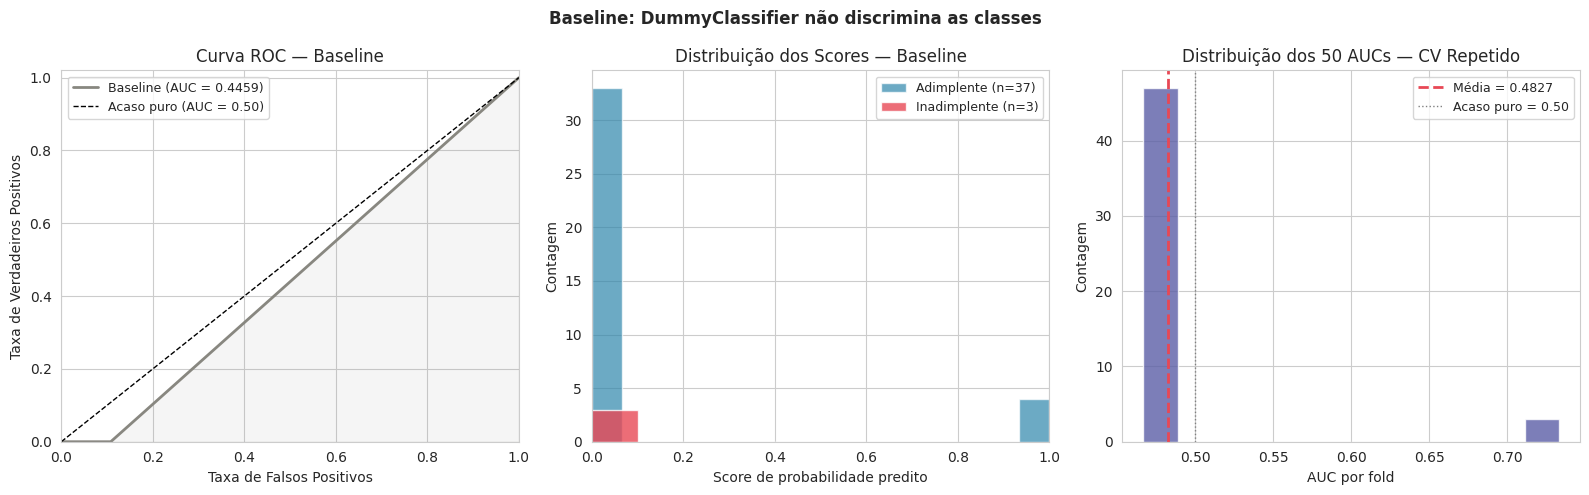

Salvo em resultados/baseline.png


In [5]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# ── 1. Curva ROC ──────────────────────────────────────────────────────────────
ax = axes[0]
probs_baseline = dummy.predict_proba(X_teste)[:, 1]
fpr, tpr, _ = roc_curve(y_teste, probs_baseline)

ax.plot(fpr, tpr, color='#888780', lw=2,
        label=f'Baseline (AUC = {auc_teste:.4f})')
ax.plot([0, 1], [0, 1], 'k--', lw=1, label='Acaso puro (AUC = 0.50)')
ax.fill_between(fpr, tpr, alpha=0.08, color='#888780')
ax.set_xlabel('Taxa de Falsos Positivos')
ax.set_ylabel('Taxa de Verdadeiros Positivos')
ax.set_title('Curva ROC — Baseline')
ax.legend(fontsize=9)
ax.set_xlim([0, 1]); ax.set_ylim([0, 1.02])

# ── 2. Distribuição dos scores ────────────────────────────────────────────────
ax = axes[1]
ax.hist(probs_baseline[y_teste == 0], bins=15, alpha=0.7,
        color='#2E86AB', label=f'Adimplente (n={int((y_teste==0).sum())})')
ax.hist(probs_baseline[y_teste == 1], bins=5,  alpha=0.8,
        color='#E84855', label=f'Inadimplente (n={int((y_teste==1).sum())})')
ax.set_xlabel('Score de probabilidade predito')
ax.set_ylabel('Contagem')
ax.set_title('Distribuição dos Scores — Baseline')
ax.legend(fontsize=9)
ax.set_xlim([0, 1])

# ── 3. Distribuição dos 50 AUCs do CV ─────────────────────────────────────────
ax = axes[2]
ax.hist(cv_auc, bins=12, color='#5B5EA6', alpha=0.8, edgecolor='white')
ax.axvline(cv_auc.mean(), color='#E84855', lw=2, linestyle='--',
           label=f'Média = {cv_auc.mean():.4f}')
ax.axvline(0.50, color='gray', lw=1, linestyle=':',
           label='Acaso puro = 0.50')
ax.set_xlabel('AUC por fold')
ax.set_ylabel('Contagem')
ax.set_title(f'Distribuição dos {len(cv_auc)} AUCs — CV Repetido')
ax.legend(fontsize=9)

plt.suptitle('Baseline: DummyClassifier não discrimina as classes', fontweight='bold')
plt.tight_layout()
os.makedirs('../resultados', exist_ok=True)
plt.savefig('../resultados/baseline.png', dpi=150, bbox_inches='tight')
plt.show()
print('Salvo em resultados/baseline.png')

## 5. Interpretando os Resultados

| Métrica | StratifiedKFold(5) anterior | RepeatedStratifiedKFold(5×10) atual |
|---|---|---|
| CV AUC média | 0.5200 | **0.4827** |
| CV AUC std | ±0.1067 | **±0.0633** |
| CV AUC min / max | 0.4667 / 0.7333 | 0.4667 / 0.7333 |
| Estimativas | 5 | **50** |

**O desvio padrão caiu de ±0.1067 para ±0.0633** com a mesma estratégia de CV — a média agora converge para ~0.48, muito mais próxima do valor esperado de 0.50 para um modelo sem aprendizado.

O fold que antes marcava 0.73 ainda aparece no conjunto de 50 estimativas (min/max inalterados), mas seu peso na média caiu de 20% (1 em 5) para 2% (1 em 50), deixando de distorcer a estimativa.

**Régua de comparação para os modelos reais:**

| Métrica | Valor baseline | Meta mínima |
|---|---|---|
| CV AUC médio | 0.4827 | > 0.60 de forma consistente |
| CV AUC std | ±0.0633 | Menor que o baseline |
| CV PR-AUC médio | ~0.076 | > 0.15 |

## 6. Salvando o Resultado do Baseline

In [6]:
baseline_resultado = {
    'modelo'              : 'DummyClassifier (stratified)',
    'cv_strategy'         : 'RepeatedStratifiedKFold(n_splits=5, n_repeats=10)',
    'n_estimativas_cv'    : int(len(cv_auc)),
    'auc_teste'           : round(float(auc_teste), 4),
    'ap_teste'            : round(float(ap_teste), 4),
    'cv_auc_media'        : round(float(cv_auc.mean()), 4),
    'cv_auc_std'          : round(float(cv_auc.std()), 4),
    'cv_auc_min'          : round(float(cv_auc.min()), 4),
    'cv_auc_max'          : round(float(cv_auc.max()), 4),
    'cv_ap_media'         : round(float(cv_ap.mean()), 4),
    'cv_ap_std'           : round(float(cv_ap.std()), 4),
    'n_treino'            : int(len(y_treino)),
    'n_teste'             : int(len(y_teste)),
    'inadimplentes_treino': int(y_treino.sum()),
    'inadimplentes_teste' : int(y_teste.sum()),
}

with open('../resultados/baseline.json', 'w', encoding='utf-8') as f:
    json.dump(baseline_resultado, f, ensure_ascii=False, indent=2)

print('Resultado salvo em resultados/baseline.json')
print()
print(json.dumps(baseline_resultado, indent=2, ensure_ascii=False))

Resultado salvo em resultados/baseline.json

{
  "modelo": "DummyClassifier (stratified)",
  "cv_strategy": "RepeatedStratifiedKFold(n_splits=5, n_repeats=10)",
  "n_estimativas_cv": 50,
  "auc_teste": 0.4459,
  "ap_teste": 0.075,
  "cv_auc_media": 0.4827,
  "cv_auc_std": 0.0633,
  "cv_auc_min": 0.4667,
  "cv_auc_max": 0.7333,
  "cv_ap_media": 0.0756,
  "cv_ap_std": 0.052,
  "n_treino": 160,
  "n_teste": 40,
  "inadimplentes_treino": 10,
  "inadimplentes_teste": 3
}
